# Redes Neuronales (Intro)

##### Imitan el comportamiendo humano, simulan un grafo interconectado cuyos nodos son neuronas y está organizado por capas. 
- Input Layer
- Hidden Layer
- Output Layer

##### Cada conexión tiene un peso (una importancia) y cada nodo aplica una función matemática (normalmente no lineal) para producir su salida.
##### La idea básica es que, al ajustar los pesos de las conexiones, la red aprende a predecir la salida correcta a partir de los datos de entrada.

#### Tipos de Variables
- Entrada: numéricas (y categorizadas con números)
- Salida: 
    - una clase (clasificación): softmax o sigmoide como función de activación.
    - un valor continuo (regresión): función de activación lineal

#### Pasos de entrenamiento:
1. Forward Propagation: 
    - Cada input multiplica pesos y suma un sesgo (bias).
    - El resultado pasa por una función de activación (como relu, tanh o logistic), que introduce no linealidad y permite a la red modelar relaciones complejas.
    - Esto se repite capa por capa hasta generar la predicción final. 
2. Cálculo del loss:
    - Se calcula la diferencia entre la predicción (ŷ) y el valor real (y) usando una loss function.
    - Cuando es categórico, usamos Cross-Entropy. Cuando es regresión, usamos MSE
    - Con esto sabemos qué tan mal predijo/apredió la red.
3. Back Propagation:
    - Se usa el loss error para calcular los gradientes (usando derivadas parciales) de los pesos respecto al error.
    - Los gradientes muestran cómo debería ajustarse cada peso para reducir el error.
4. Actualización de pesos
    - Ajustamos pesos: nuevo_peso = peso_actual - (learning_rate × gradiente)
    - El learning rate controla qué tan grande es cada ajuste.
        - Muy pequeño → aprendizaje lento.
        - Muy grande → riesgo de inestabilidad y divergencia.
5. Repeat (Iteraciones / Epochs):
    - Repetimos los pasos anteriores hasta que:
        - Se va estabilizando el loss
        - Cumplimos un número finito de iteraciones
        - manejamos un margen de tolerancia

## Cargando el conjunto de datos

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.compose import make_column_selector as selector #Para seleccionar de forma automática las variables numéricas y categóricas
from sklearn.preprocessing import OneHotEncoder #Para codificar las variables categóricas usando dummies
from sklearn.preprocessing import StandardScaler #Para normalizar las variables numéricas
from sklearn.compose import ColumnTransformer #Modifica las columnas usando los preprocesadores
from sklearn.pipeline import make_pipeline #Planifica una secuencia de procesos
from sklearn import set_config #Para mostrar graficamente el pipeline
from sklearn.model_selection import GridSearchCV

set_config(display='diagram')
#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score

In [2]:
iris = datasets.load_iris()
#Transformando a un dataframe de pandas
datos = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])
#Cambiandole los nombres a las columnas
datos.columns=["Sepal.length","Sepal.width","Petal.length","Petal.width","Specie"]
datos.head()

,Sepal.length,Sepal.width,Petal.length,Petal.width,Specie
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


## Obteniendo la variable respuesta

In [3]:
y = datos.pop("Specie")

print(y)
print(datos.head())

0      0.0
1      0.0
2      0.0
3      0.0
4      0.0
      ... 
145    2.0
146    2.0
147    2.0
148    2.0
149    2.0
Name: Specie, Length: 150, dtype: float64
   Sepal.length  Sepal.width  Petal.length  Petal.width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


Text(0.5, 1.0, 'Correlación de las variables numéricas de Iris')

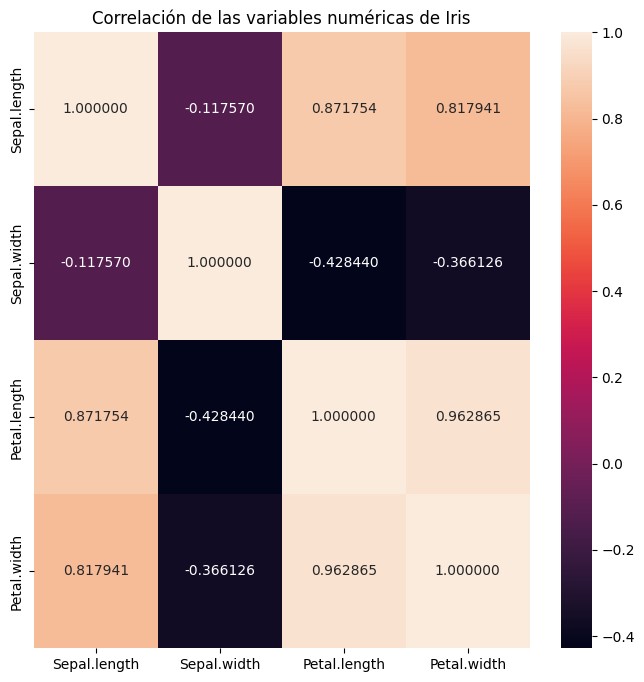

In [4]:
plt.subplots(figsize = (8,8))
sns.heatmap(datos.corr(),annot=True,fmt="f").set_title("Correlación de las variables numéricas de Iris")

### Separando en train y test

In [5]:
X = datos #El resto de los datos
random.seed(123)

In [6]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7)

70% de entrenamiento y 30% prueba

In [7]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 11 to 20
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.length  105 non-null    float64
 1   Sepal.width   105 non-null    float64
 2   Petal.length  105 non-null    float64
 3   Petal.width   105 non-null    float64
dtypes: float64(4)
memory usage: 4.1 KB


In [8]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 82 to 56
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.length  45 non-null     float64
 1   Sepal.width   45 non-null     float64
 2   Petal.length  45 non-null     float64
 3   Petal.width   45 non-null     float64
dtypes: float64(4)
memory usage: 1.8 KB


In [9]:
X.describe()

,Sepal.length,Sepal.width,Petal.length,Petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Normalizando los datos

In [10]:
scaler = StandardScaler()
scaler.fit(X)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:3])

[[-1.26418478  0.78880759 -1.22655167 -1.3154443 ]
 [-0.41600969 -1.74335684  0.13754657  0.13250973]
 [-1.26418478 -0.13197948 -1.34022653 -1.18381211]]


### Creando el modelo

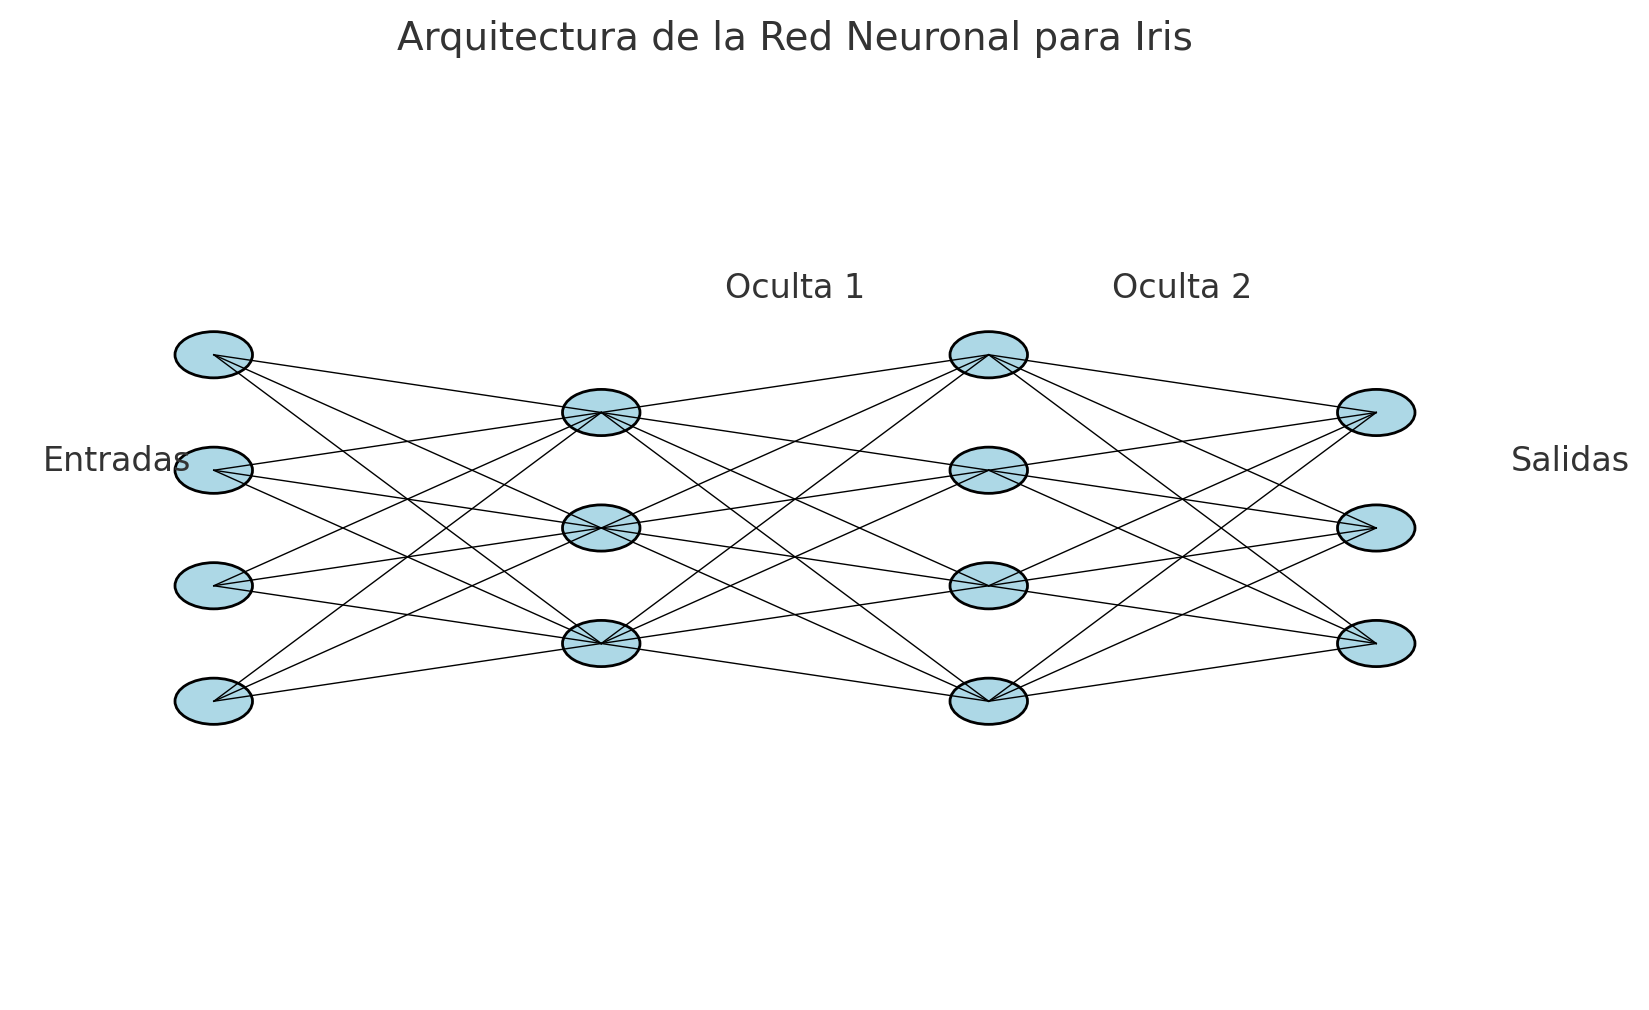

Loss: indica qué tan mal lo está haciendo el modelo en una iteración.
Cuanto menor el valor de la pérdida, mejor la NN está ajustando sus pesos para predecir correctamente.

In [11]:
# Colocamos el Verbose = True para visualizar la pérdida por iteración
# Multi-Layer Perceptron Classifier
mlp = MLPClassifier(hidden_layer_sizes=(3,4), max_iter=1000, verbose=True)
mlp.fit(X_train,y_train)
y_pred = mlp.predict(X_test)
y_pred

Iteration 1, loss = 1.68366522
Iteration 2, loss = 1.67735190
Iteration 3, loss = 1.67107716
Iteration 4, loss = 1.66483802
Iteration 5, loss = 1.65863370
Iteration 6, loss = 1.65246449
Iteration 7, loss = 1.64633075
Iteration 8, loss = 1.64023283
Iteration 9, loss = 1.63418006
Iteration 10, loss = 1.62816739
Iteration 11, loss = 1.62219194
Iteration 12, loss = 1.61625279
Iteration 13, loss = 1.61034919
Iteration 14, loss = 1.60449526
Iteration 15, loss = 1.59868256
Iteration 16, loss = 1.59290782
Iteration 17, loss = 1.58717073
Iteration 18, loss = 1.58146998
Iteration 19, loss = 1.57580676
Iteration 20, loss = 1.57018098
Iteration 21, loss = 1.56460378
Iteration 22, loss = 1.55906633
Iteration 23, loss = 1.55356677
Iteration 24, loss = 1.54810492
Iteration 25, loss = 1.54268055
Iteration 26, loss = 1.53729173
Iteration 27, loss = 1.53193734
Iteration 28, loss = 1.52661959
Iteration 29, loss = 1.52133826
Iteration 30, loss = 1.51609315
Iteration 31, loss = 1.51088400
Iteration 32, los

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


array([1., 1., 1., 1., 2., 2., 1., 2., 2., 0., 2., 0., 1., 1., 1., 1., 2.,
       0., 0., 0., 1., 2., 1., 1., 0., 2., 2., 2., 0., 2., 2., 2., 0., 0.,
       1., 0., 2., 2., 2., 2., 2., 2., 1., 2., 1.])

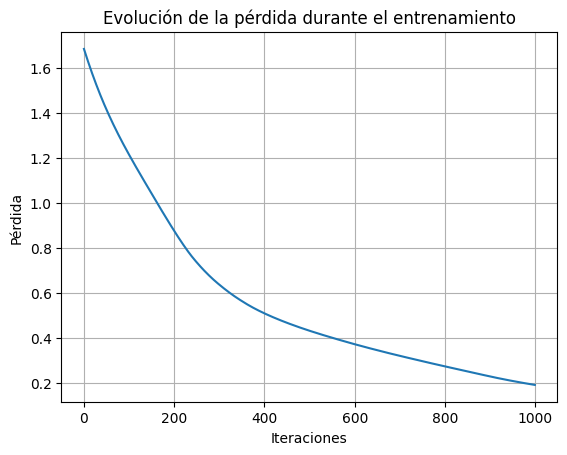

In [12]:
# Después del fit
plt.plot(mlp.loss_curve_)
plt.title('Evolución de la pérdida durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid()
plt.show()


## ¿Cómo podemos interpretar esta gráfica? 
#
#
#
#### ¿Por qué necesitamos tantas iteraciones (en comparación a la cantidad de registros que tenemos en el dataset) para que la pérdida se aplane?

- La red es más grande de lo necesario
- Los datos no son perfectamente separables (Versicolor y Virginica se parecen)
- Inicialización aleatoria de pesos ( empieza en un punto muy malo y le cuesta ajustarse en varias iteraciones )
- Learning rate bajo
- Complejidad en la data

In [13]:
cm = confusion_matrix(y_test,y_pred)
accuracy=accuracy_score(y_test,y_pred)
precision =precision_score(y_test, y_pred,average='micro')
recall =  recall_score(y_test, y_pred,average='micro')
f1 = f1_score(y_test,y_pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

Matriz de confusión
 [[10  0  0]
 [ 0 14  1]
 [ 0  1 19]]
Accuracy:  0.9555555555555556
Precision:  0.9555555555555556
recall:  0.9555555555555556


### Tuneando parámetros
Vamos a trabajar con el conjunto de datos de titanic

In [29]:
datos = pd.read_csv("titanic.csv")

Comprobando que se cargaron los datos correctamente.

In [30]:
datos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Vamos a quitar las columnas que ya vimos en ejemplos anteriores que no van a aportar a ningún modelo que hagamos. Por ejemplo el id del pasajero, el nombre, la cabina y el ticket

In [31]:
datos.pop("PassengerId")
datos.pop("Name")
datos.pop("Cabin")
datos.pop("Ticket")

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

Comprobemos que fueron eliminadas las columnas

In [32]:
print(datos.shape)
print(datos.columns)

(891, 8)
Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')


Veamos de que tipo son las variables de nuestro conjunto de datos

In [33]:
datos['Age'].fillna(datos['Age'].median(), inplace=True) #Llenando los Na de la edad con la mediana
print(datos.describe())
datos.dropna(inplace=True)
print(datos.isnull().sum())
datos["Sex"] = datos["Sex"].astype(str)
datos["Embarked"] = datos["Embarked"].astype(str)
print(datos.dtypes)

         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.361582    0.523008    0.381594   32.204208
std      0.486592    0.836071   13.019697    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   22.000000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   35.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

/var/folders/9q/tfydcr6d56x3ht8bfg6vfx240000gn/T/ipykernel_54230/4154736288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos['Age'].fillna(datos['Age'].median(), inplace=True) #Llenando los Na de la edad con la mediana


Hay 3 variables categóricas y 3 numéricas. Las categóricas son Pclass, Embarked y la variable respuesta. Las otras 3 son numéricas

Si se fija, las variables categóricas casi siempre estpan como string por lo que el tipo de datos es Object, pero Object no es exclusivo de variables que guardan texto, por lo que hay que ser cuidadoses a la hora de separarlas de forma automática. 

In [34]:
#la variable respuesta
print(datos.groupby('Survived').size())
target = datos.pop("Survived")

Survived
0    549
1    340
dtype: int64


In [35]:
#Creamos los selectores
selector_numericas = selector(dtype_exclude=object) #Seleccionamos todas las variables que no son Object
selector_categoricas = selector(dtype_include=object) #Seleccionamos todas las varibles de tipo object
#Seleccionamos las columnas que cumplen con los selectores pasándole los datos
numericas = selector_numericas(datos)
categoricas = selector_categoricas(datos)
#veamos que tan bien separó las variables
print("Numéricas: ",numericas)
print("Categóricas: ", categoricas)


Numéricas:  ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categóricas:  ['Sex', 'Embarked']


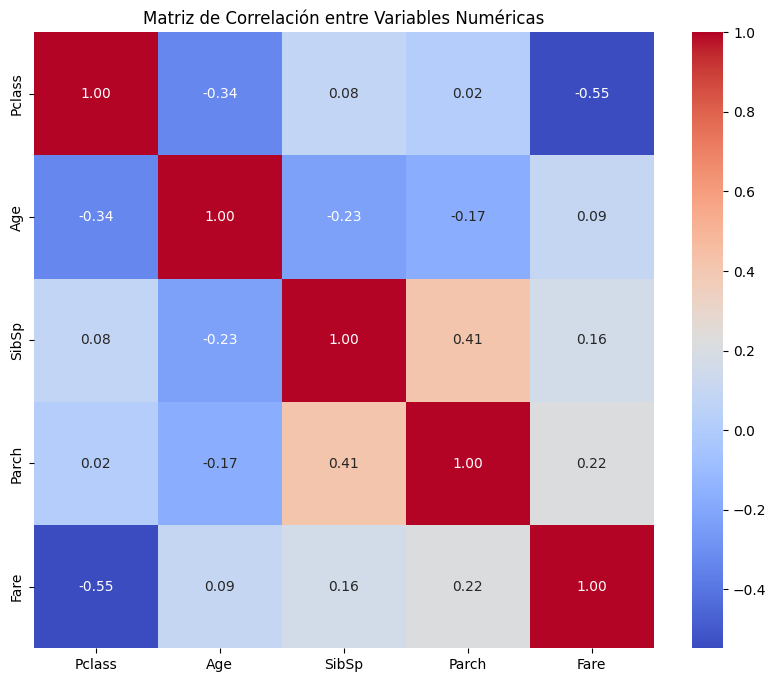

In [36]:
plt.figure(figsize=(10, 8))
corr = datos[numericas].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.show()

Ahora vamos a crear los objetos de los preprocesadores

In [37]:
preprocesador_categorico = OneHotEncoder(handle_unknown="ignore")
preprocesador_numerico = StandardScaler()

Ahora creamos el objeto que transformará las columnas con los preprocesadores correspondientes al tipo de variable

In [38]:
preprocesador = ColumnTransformer([
    ('one_hot_encoder',preprocesador_categorico,categoricas),
    ('standard_scaler',preprocesador_numerico, numericas)
])

Nótese que hasta aquí no se ha hecho ningún cambio, solo hemos creado los objetos que se utilizarán en el pipeline. <br>
Vamos a crear el modelo a continuación: <br>
Se creará un perceptrón multicapa con dos capas ocultas de 5 y 3 neuronas respectivamente con función de activación de tangente hiperbólica

In [39]:
modelo = make_pipeline(preprocesador,MLPClassifier(activation="tanh",verbose=True,hidden_layer_sizes=(5,3)))
modelo

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare'])])),
                ('mlpclassifier',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3),
                               verbose=True))])

Ya tenemos creado el modelo. Vamos a dividir los datos en entrenamiento y prueba usando un muestreo aleatorio simple con 70% para entrenamiento y 30% prueba.

In [41]:
data_train, data_test, target_train, target_test = train_test_split(
    datos, target, train_size=0.7,test_size=0.3)
print("Shape train",data_train.shape)
print("Shape test",data_test.shape)
datos.isnull().sum()

Shape train (622, 7)
Shape test (267, 7)


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Vamos a entrenar el modelo

In [42]:
modelo.fit(data_train,target_train)

Iteration 1, loss = 0.69877887
Iteration 2, loss = 0.69305809
Iteration 3, loss = 0.68805410
Iteration 4, loss = 0.68327109
Iteration 5, loss = 0.67878826
Iteration 6, loss = 0.67449650
Iteration 7, loss = 0.67035266
Iteration 8, loss = 0.66666567
Iteration 9, loss = 0.66336950
Iteration 10, loss = 0.65975103
Iteration 11, loss = 0.65666639
Iteration 12, loss = 0.65357805
Iteration 13, loss = 0.65062316
Iteration 14, loss = 0.64789574
Iteration 15, loss = 0.64505105
Iteration 16, loss = 0.64244447
Iteration 17, loss = 0.64005283
Iteration 18, loss = 0.63757090
Iteration 19, loss = 0.63511994
Iteration 20, loss = 0.63292353
Iteration 21, loss = 0.63083108
Iteration 22, loss = 0.62886475
Iteration 23, loss = 0.62691974
Iteration 24, loss = 0.62499745
Iteration 25, loss = 0.62311707
Iteration 26, loss = 0.62117603
Iteration 27, loss = 0.61917662
Iteration 28, loss = 0.61721542
Iteration 29, loss = 0.61537757
Iteration 30, loss = 0.61356238
Iteration 31, loss = 0.61172631
Iteration 32, los

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('one_hot_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'Embarked']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare'])])),
                ('mlpclassifier',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3),
                               verbose=True))])

Ahora vamos a predecir con el modelo

In [43]:
pred = modelo.predict(data_test)
pred[:5]

array([0, 1, 1, 1, 0])

In [44]:
cm = confusion_matrix(target_test,pred)
accuracy=accuracy_score(target_test,pred)
precision =precision_score(target_test,pred,average='micro')
recall =  recall_score(target_test,pred,average='micro')
f1 = f1_score(target_test,pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

Matriz de confusión
 [[141  35]
 [ 27  64]]
Accuracy:  0.7677902621722846
Precision:  0.7677902621722846
recall:  0.7677902621722846


Tenemos un accuracy de 77% <br>
#### Tuneo de parámetros usando grid search cross validation

Con la función get_params del clasificador podemos saber cuales fueron los nombres y valores de los parámetros del modelo

In [46]:
modelo.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('one_hot_encoder',
                                    OneHotEncoder(handle_unknown='ignore'),
                                    ['Sex', 'Embarked']),
                                   ('standard_scaler', StandardScaler(),
                                    ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'])])),
  ('mlpclassifier',
   MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3), verbose=True))],
 'transform_input': None,
 'verbose': False,
 'columntransformer': ColumnTransformer(transformers=[('one_hot_encoder',
                                  OneHotEncoder(handle_unknown='ignore'),
                                  ['Sex', 'Embarked']),
                                 ('standard_scaler', StandardScaler(),
                                  ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare'])]),
 'mlpclassifier': MLPClassifier(activation='tanh', hidden_layer_sizes=(5, 3), verbose=True),
 'column

Los parámetros que son tunneables de la red neuronal aparecerán con el prefijo mlpclassifier_ <br>
Hagamos una lista de parámetros a tunnear

In [47]:
parametros_tun  = param_grid = {
    'mlpclassifier__max_iter': (100,200,500,1000),
    'mlpclassifier__learning_rate_init': (0.01, 0.1, 1,10),
    'mlpclassifier__hidden_layer_sizes':((3,2),(5,3),(10,2))}
model_grid_search = GridSearchCV(modelo, param_grid=parametros_tun,
                                 n_jobs=2, cv=10) #Vamos a usar dos procesadores(n_jobs), y 10 k-folds
model_grid_search.fit(data_train, target_train)

Iteration 1, loss = 1.36189780
Iteration 1, loss = 0.69304324
Iteration 2, loss = 1.23753214
Iteration 2, loss = 0.66942096
Iteration 3, loss = 1.11395007
Iteration 3, loss = 0.65097875
Iteration 4, loss = 1.00436848
Iteration 4, loss = 0.63508563
Iteration 5, loss = 0.90652520
Iteration 5, loss = 0.62156256
Iteration 6, loss = 0.82760716
Iteration 6, loss = 0.60933168
Iteration 7, loss = 0.76524954
Iteration 7, loss = 0.59844223
Iteration 8, loss = 0.71697102
Iteration 8, loss = 0.58872222
Iteration 9, loss = 0.68107895
Iteration 9, loss = 0.57986351
Iteration 10, loss = 0.65353058
Iteration 10, loss = 0.57112879
Iteration 11, loss = 0.62946290
Iteration 11, loss = 0.56263719
Iteration 12, loss = 0.60930893
Iteration 12, loss = 0.55519984
Iteration 13, loss = 0.59294773
Iteration 13, loss = 0.54689958
Iteration 14, loss = 0.57708587
Iteration 14, loss = 0.53832796
Iteration 15, loss = 0.56314846
Iteration 15, loss = 0.52869124
Iteration 16, loss = 0.54997176
Iteration 16, loss = 0.518

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iteration

Iteration 60, loss = 0.41835629
Iteration 66, loss = 0.41358342
Iteration 61, loss = 0.41768906
Iteration 67, loss = 0.41291816
Iteration 62, loss = 0.41753868
Iteration 68, loss = 0.41200132
Iteration 63, loss = 0.41671989
Iteration 69, loss = 0.41169560
Iteration 64, loss = 0.41617808
Iteration 70, loss = 0.41093351
Iteration 65, loss = 0.41587265
Iteration 71, loss = 0.41018870
Iteration 66, loss = 0.41502934
Iteration 72, loss = 0.41006419
Iteration 67, loss = 0.41497906
Iteration 73, loss = 0.40947314
Iteration 68, loss = 0.41410058
Iteration 74, loss = 0.40899346
Iteration 69, loss = 0.41367671
Iteration 75, loss = 0.40856136
Iteration 70, loss = 0.41328189
Iteration 76, loss = 0.40801993
Iteration 71, loss = 0.41270861
Iteration 77, loss = 0.40795887
Iteration 72, loss = 0.41207665
Iteration 78, loss = 0.40736449
Iteration 73, loss = 0.41146424
Iteration 79, loss = 0.40707082
Iteration 74, loss = 0.41111837
Iteration 80, loss = 0.40689275
Iteration 75, loss = 0.41061777
Iteratio

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iteration

Iteration 146, loss = 0.38900015
Iteration 156, loss = 0.39713344
Iteration 147, loss = 0.38831346
Iteration 157, loss = 0.39709890
Iteration 148, loss = 0.38816110
Iteration 158, loss = 0.39690581
Iteration 149, loss = 0.38812927
Iteration 159, loss = 0.39664338
Iteration 150, loss = 0.38782688
Iteration 160, loss = 0.39616016
Iteration 161, loss = 0.39629022
Iteration 151, loss = 0.38769821
Iteration 162, loss = 0.39605971
Iteration 152, loss = 0.38759661
Iteration 163, loss = 0.39579084
Iteration 153, loss = 0.38732039
Iteration 164, loss = 0.39568548
Iteration 154, loss = 0.38728497
Iteration 165, loss = 0.39540221
Iteration 155, loss = 0.38703182
Iteration 166, loss = 0.39562920
Iteration 156, loss = 0.38685654
Iteration 167, loss = 0.39498295
Iteration 157, loss = 0.38672260
Iteration 168, loss = 0.39460689
Iteration 158, loss = 0.38658177
Iteration 159, loss = 0.38660344
Iteration 169, loss = 0.39488145
Iteration 160, loss = 0.38620426
Iteration 170, loss = 0.39434646
Iteration 

...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 8, loss = 0.44199268
Iteration 607, loss = 0.26361093
Iteration 9, loss = 0.42933489
Iteration 608, loss = 0.26356415
Iteration 10, loss = 0.40921576
Iteration 609, loss = 0.26382979
Iteration 11, loss = 0.40773357
Iteration 610, loss = 0.26446051
Iteration 12, loss = 0.40299189
Iteration 611, loss = 0.26327468
Iteration 13, loss = 0.39706421
Iteration 612, loss = 0.26474673
Iteration 14, loss = 0.39767804
Iteration 613, loss = 0.26332177
Iteration 15, loss = 0.39416265
Iteration 614, loss = 0.26576944
Iteration 16, loss = 0.39263600
Iteration 615, loss = 0.26353893
Iteration 17, loss = 0.38897046
Iteration 616, loss = 0.26471798
Iteration 18, loss = 0.38998494
Iteration 617, loss = 0.26537559
Iteration 19, loss = 0.38637373
Iteration 618, loss = 0.26354509
Iteration 20, loss = 0.38608332
Iteration 619, loss = 0.26234449
Iteration 21, loss = 0.38524814
Iteration 620, loss = 0.26445825
Iteration 22, loss = 0.38668588
Iteration 621, loss = 0.26319888
Iteration 23, loss = 0.3835

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 74, loss = 0.32573580
Iteration 43, loss = 0.34870736
Iteration 75, loss = 0.32953657
Iteration 44, loss = 0.35319098
Iteration 76, loss = 0.32405928
Iteration 45, loss = 0.35708623
Iteration 77, loss = 0.32874917
Iteration 46, loss = 0.34349857
Iteration 78, loss = 0.33252269
Iteration 47, loss = 0.34799546Iteration 79, loss = 0.33396250

Iteration 48, loss = 0.34390204
Iteration 80, loss = 0.33091929
Iteration 49, loss = 0.34600750
Iteration 81, loss = 0.32721327
Iteration 50, loss = 0.34317992
Iteration 82, loss = 0.33110017
Iteration 51, loss = 0.34027554
Iteration 83, loss = 0.32559198
Iteration 52, loss = 0.33658854
Iteration 84, loss = 0.33113589
Iteration 85, loss = 0.32467145
Iteration 53, loss = 0.33846299
Iteration 86, loss = 0.32906766
Iteration 54, loss = 0.33715761
Iteration 87, loss = 0.32837225
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Iteration 55, loss = 0.33293785
Iteration 56, loss = 0.33796429
Iteration 57, 

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('one_hot_encoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Embarked']),
                                                                        ('standard_scaler',
                                                                         StandardScaler(),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare'])])),
                                       ('mlpclassifier',
                                        MLPClassifier(activation='tanh',
                                                      hidden_layer_sizes=(5, 3),
                                                      verbose=True))]),
             n_jobs=2,
             param_grid={'mlpclassifier__hidden_layer_sizes': ((3, 2), (5, 3),
                                                               (10, 2)),
                         'mlpclassifier__learning_rate_init': (0.01, 0.1, 1,
                                                               10),
                         'mlpclassifier__max_iter': (100, 200, 500, 1000)})

¿Cuál será la mejor combinación de parámetros?


In [48]:
model_grid_search.best_params_

{'mlpclassifier__hidden_layer_sizes': (10, 2),
 'mlpclassifier__learning_rate_init': 0.1,
 'mlpclassifier__max_iter': 100}

Vamos a predecir con el mejor modelo

In [49]:
pred = model_grid_search.predict(data_test)

In [50]:
pred

array([0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1])

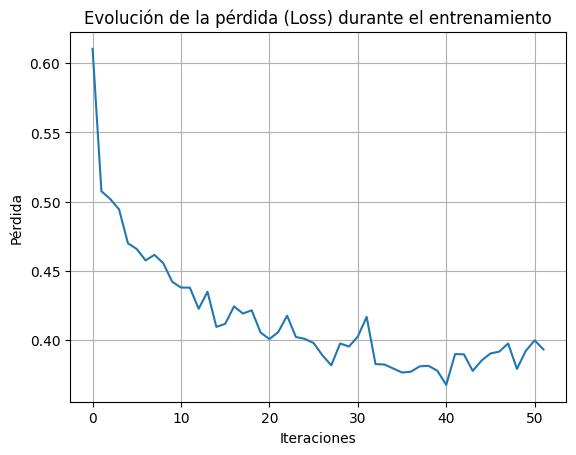

In [51]:
# Accedemos al mejor modelo (el que GridSearchCV encontró)
mejor_modelo = model_grid_search.best_estimator_

mlp_final = mejor_modelo.named_steps['mlpclassifier']

# Ahora graficamos su loss_curve_
plt.plot(mlp_final.loss_curve_)
plt.title('Evolución de la pérdida (Loss) durante el entrenamiento')
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.grid(True)
plt.show()

In [52]:
cm = confusion_matrix(target_test,pred)
accuracy=accuracy_score(target_test,pred)
precision =precision_score(target_test,pred,average='micro')
recall =  recall_score(target_test,pred,average='micro')
f1 = f1_score(target_test,pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

Matriz de confusión
 [[154  22]
 [ 25  66]]
Accuracy:  0.8239700374531835
Precision:  0.8239700374531835
recall:  0.8239700374531835


Como se puede ver el accuracy mejoró un poco. 
#
Veamos otro approach para ver si logramos mejorarlo más.


In [53]:
# Try 2
parametros_tun = {
    'mlpclassifier__activation': ['relu', 'tanh'],
    'mlpclassifier__solver': ['adam', 'lbfgs'],
    'mlpclassifier__alpha': [0.0001, 0.001, 0.01],
    'mlpclassifier__hidden_layer_sizes': [(2,2), (64,32), (10,), (6,4)],
    'mlpclassifier__learning_rate_init': [0.001, 0.01, 0.003],
    'mlpclassifier__max_iter': [300, 500, 1000],
    'mlpclassifier__early_stopping': [True]
}
model_grid_search = GridSearchCV(modelo, param_grid=parametros_tun,
                                 n_jobs=2, cv=10) #Vamos a usar dos procesadores(n_jobs), y 10 k-folds
model_grid_search.fit(data_train, target_train)

Iteration 1, loss = 0.72633732
Validation score: 0.607143
Iteration 2, loss = 0.72382412
Validation score: 0.607143
Iteration 3, loss = 0.72143941
Validation score: 0.607143
Iteration 4, loss = 0.71918176
Validation score: 0.607143
Iteration 5, loss = 0.71699502
Validation score: 0.607143
Iteration 6, loss = 0.71488888
Validation score: 0.607143
Iteration 7, loss = 0.71264782
Validation score: 0.607143
Iteration 8, loss = 0.71072016
Validation score: 0.607143
Iteration 9, loss = 0.70894707
Validation score: 0.607143
Iteration 10, loss = 0.70687272
Validation score: 0.607143
Iteration 11, loss = 0.70513472
Validation score: 0.607143
Iteration 12, loss = 0.70348378
Validation score: 0.607143
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Iteration 1, loss = 0.74205399
Validation score: 0.607143
Iteration 2, loss = 0.74150523
Validation score: 0.607143
Iteration 3, loss = 0.74099510
Validation score: 0.607143
Iteration 4, loss = 0.74042827
Val

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Iteration 1, loss = 0.98859924
Validation score: 0.392857
Iteration 2, loss = 0.98749884
Validation score: 0.392857
Iteration 3, loss = 0.98640122
Validation score: 0.392857
Iteration 4, loss = 0.98527901
Validation score: 0.392857
Iteration 5, loss = 0.98418739
Validation score: 0.392857
Iteration 6, loss = 0.98307898
Validation score: 0.392857
Iteration 7, loss = 0.98197870
Validation score: 0.392857
Iteration 8, loss = 0.98086287
Validation score: 0.392857
Iteration 9, loss = 0.97980868
Validation score: 0.392857
Iteration 10, loss = 0.97864581
Validation score: 0.392857
Iteration 11, loss = 0.97760709
Validation score: 0.392857
Iteration 12, loss = 0.97650944
Validation score: 0.392857
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Iteration 1, loss = 0.92129789
Validation score: 0.392857
Iteration 2, loss = 0.91785710
Validation score: 0.392857
Iteration 3, loss = 0.91462918
Validation score: 0.392857
Iteration 4, loss = 0.91134883
Val

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Iteration 1, loss = 0.95608735
Validation score: 0.392857
Iteration 2, loss = 0.95494010
Validation score: 0.392857
Iteration 3, loss = 0.95370619
Validation score: 0.392857
Iteration 4, loss = 0.95252290
Validation score: 0.392857
Iteration 5, loss = 0.95144692
Validation score: 0.392857
Iteration 6, loss = 0.95030885
Validation score: 0.392857
Iteration 7, loss = 0.94919130
Validation score: 0.392857
Iteration 8, loss = 0.94808033
Validation score: 0.392857
Iteration 9, loss = 0.94704673
Validation score: 0.392857
Iteration 10, loss = 0.94594280
Validation score: 0.392857
Iteration 11, loss = 0.94493131
Validation score: 0.392857
Iteration 12, loss = 0.94387342
Validation score: 0.392857
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Iteration 1, loss = 0.99200625
Validation score: 0.392857
Iteration 2, loss = 0.98642141
Validation score: 0.392857
Iteration 3, loss = 0.98125668
Validation score: 0.392857
Iteration 4, loss = 0.97599342
Val

...

Iteration 1, loss = 1.08872599
Validation score: 0.428571
Iteration 2, loss = 1.03059612
Validation score: 0.482143
Iteration 3, loss = 0.97257669
Validation score: 0.482143
Iteration 4, loss = 0.92180458
Validation score: 0.500000
Iteration 5, loss = 0.87159736
Validation score: 0.517857
Iteration 6, loss = 0.82747002
Validation score: 0.553571
Iteration 7, loss = 0.78601066
Validation score: 0.678571
Iteration 8, loss = 0.75121991
Validation score: 0.767857
Iteration 9, loss = 0.71886797
Validation score: 0.803571
Iteration 10, loss = 0.69358313
Validation score: 0.821429
Iteration 11, loss = 0.66957537
Validation score: 0.839286
Iteration 12, loss = 0.65007990
Validation score: 0.857143
Iteration 13, loss = 0.63200078
Validation score: 0.857143
Iteration 14, loss = 0.61587470
Validation score: 0.857143
Iteration 15, loss = 0.60207764
Validation score: 0.857143
Iteration 16, loss = 0.58901116
Validation score: 0.857143
Iteration 17, loss = 0.57806819
Validation score: 0.875000
Iterat

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network

Iteration 1, loss = 0.67865771
Validation score: 0.650794
Iteration 2, loss = 0.62437536
Validation score: 0.682540
Iteration 3, loss = 0.57975928
Validation score: 0.682540
Iteration 4, loss = 0.54007718
Validation score: 0.714286
Iteration 5, loss = 0.50925868
Validation score: 0.730159
Iteration 6, loss = 0.48035224
Validation score: 0.730159
Iteration 7, loss = 0.45975649
Validation score: 0.793651
Iteration 8, loss = 0.44126493
Validation score: 0.793651
Iteration 9, loss = 0.43085341
Validation score: 0.777778
Iteration 10, loss = 0.42196491
Validation score: 0.777778
Iteration 11, loss = 0.41650342
Validation score: 0.777778
Iteration 12, loss = 0.41331333
Validation score: 0.793651
Iteration 13, loss = 0.41097959
Validation score: 0.793651
Iteration 14, loss = 0.40695862
Validation score: 0.777778
Iteration 15, loss = 0.40253144
Validation score: 0.777778
Iteration 16, loss = 0.39808691
Validation score: 0.777778
Iteration 17, loss = 0.39516248
Validation score: 0.777778
Iterat

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('one_hot_encoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['Sex',
                                                                          'Embarked']),
                                                                        ('standard_scaler',
                                                                         StandardScaler(),
                                                                         ['Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare'])])),
                                       ('mlpclassifier',
                                        MLPClassifier(activation='tanh',
                                                      hidden_layer_sizes=(5, 3),
                                                      verbose=True))]),
             n_jobs=2,
             param_grid={'mlpclassifier__activation': ['relu', 'tanh'],
                         'mlpclassifier__alpha': [0.0001, 0.001, 0.01],
                         'mlpclassifier__early_stopping': [True],
                         'mlpclassifier__hidden_layer_sizes': [(2, 2), (64, 32),
                                                               (10,), (6, 4)],
                         'mlpclassifier__learning_rate_init': [0.001, 0.01,
                                                               0.003],
                         'mlpclassifier__max_iter': [300, 500, 1000],
                         'mlpclassifier__solver': ['adam', 'lbfgs']})

In [54]:
model_grid_search.best_params_

{'mlpclassifier__activation': 'relu',
 'mlpclassifier__alpha': 0.001,
 'mlpclassifier__early_stopping': True,
 'mlpclassifier__hidden_layer_sizes': (64, 32),
 'mlpclassifier__learning_rate_init': 0.003,
 'mlpclassifier__max_iter': 500,
 'mlpclassifier__solver': 'adam'}

In [55]:
pred = model_grid_search.predict(data_test)

In [56]:
mejor_modelo = model_grid_search.best_estimator_
mejor_modelo
mlp_final = mejor_modelo.named_steps['mlpclassifier']
mlp_final

MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(64, 32),
              learning_rate_init=0.003, max_iter=500, verbose=True)

In [57]:
cm = confusion_matrix(target_test,pred)
accuracy=accuracy_score(target_test,pred)
precision =precision_score(target_test,pred,average='micro')
recall =  recall_score(target_test,pred,average='micro')
f1 = f1_score(target_test,pred,average='micro')
print('Matriz de confusión\n',cm)
print('Accuracy: ',accuracy)
print('Precision: ', precision)
print('recall: ',recall)

Matriz de confusión
 [[149  27]
 [ 29  62]]
Accuracy:  0.7902621722846442
Precision:  0.7902621722846442
recall:  0.7902621722846442


### ¿Conclusiones?